# 04 Clustering Pipeline

## Objective

This notebook builds an unsupervised clustering pipeline for the Customer Personality Analysis project. The goal is to segment customers using demographics, spending behavior, purchase behavior, recency, and historical campaign behavior.

This step does not build supervised models, create the final supervised target variable, or assign final business names to segments. Segment profiling and interpretation will happen in the next project step.

## Setup

The reusable clustering workflow lives in `src/clustering.py`. This notebook imports those functions so the executed notebook and script use the same feature choices, transformations, and model settings.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from clustering import (
    CLUSTERED_DATA_PATH,
    FEATURE_DATA_PATH,
    FINAL_K,
    K_VALUES,
    LOG_TRANSFORM_COLUMNS,
    WINSORIZE_COLUMNS,
    add_cluster_labels,
    create_pca_coordinates,
    evaluate_k_values,
    fit_final_kmeans,
    get_clustering_features,
    load_feature_data,
    prepare_clustering_matrix,
    save_clustered_output,
    validate_input_data,
)

FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

print(f"Feature data path: {FEATURE_DATA_PATH}")
print(f"Clustered output path: {CLUSTERED_DATA_PATH}")

Feature data path: /Users/arjun/Documents/Intro DS final/data/processed/customer_features.csv
Clustered output path: /Users/arjun/Documents/Intro DS final/data/processed/customer_clustered.csv


## 1. Inspect Input Data

The clustering input is `data/processed/customer_features.csv`. Before selecting features, confirm the dataset shape, missing values, infinite values, and the major concerns from EDA.

In [2]:
df = load_feature_data(FEATURE_DATA_PATH)

print(f"Input dataframe shape: {df.shape}")
display(pd.Series(validate_input_data(df), name="count").to_frame())
display(df.head())

Input dataframe shape: (2213, 53)


,count
rows,2213
columns,53
missing_values,0
infinite_values,0


,id,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mnt_wines,mnt_fruits,mnt_meat_products,mnt_fish_products,mnt_sweet_products,mnt_gold_prods,num_deals_purchases,num_web_purchases,num_catalog_purchases,num_store_purchases,num_web_visits_month,accepted_cmp3,accepted_cmp4,accepted_cmp5,accepted_cmp1,accepted_cmp2,complain,z_cost_contact,z_revenue,response,age,customer_tenure_days,customer_tenure_years,children_total,has_children,household_size,total_spending,wine_share,fruits_share,meat_share,fish_share,sweets_share,gold_share,luxury_spending_ratio,spending_per_tenure_year,total_store_web_catalog_purchases,total_purchases,web_purchase_share,store_purchase_share,catalog_purchase_share,deal_purchase_share,average_spend_per_purchase,total_campaign_acceptances,any_campaign_acceptance
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,57,663,1.815195,0,0,1,1617,0.392703,0.054422,0.337662,0.106370,0.054422,0.054422,0.447124,890.813348,22,25,0.363636,0.181818,0.454545,0.120000,73.500000,0,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,60,113,0.309377,2,1,3,27,0.407407,0.037037,0.222222,0.074074,0.037037,0.222222,0.629630,87.272124,4,6,0.250000,0.500000,0.250000,0.333333,6.750000,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,49,312,0.854209,0,0,2,776,0.548969,0.063144,0.163660,0.143041,0.027062,0.054124,0.603093,908.442308,20,21,0.400000,0.500000,0.100000,0.047619,38.800000,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,30,139,0.380561,1,1,3,53,0.207547,0.075472,0.377358,0.188679,0.056604,0.094340,0.301887,139.267986,6,8,0.333333,0.666667,0.000000,0.250000,8.833333,0,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,33,161,0.440794,1,1,3,422,0.409953,0.101896,0.279621,0.109005,0.063981,0.035545,0.445498,957.363354,14,19,0.357143,0.428571,0.214286,0.263158,30.142857,0,0


In [3]:
concern_cols = [
    "income",
    "total_spending",
    "total_purchases",
    "average_spend_per_purchase",
    "spending_per_tenure_year",
]

display(df[concern_cols].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).T)

print("Top income values")
display(df.nlargest(5, "income")[["id", "income", "total_spending", "total_purchases", "spending_per_tenure_year"]])

print("Top spending_per_tenure_year values")
display(df.nlargest(5, "spending_per_tenure_year")[["id", "income", "total_spending", "customer_tenure_days", "spending_per_tenure_year"]])

,count,mean,std,min,50%,75%,90%,95%,99%,max
income,2213.0,52236.581563,25178.603047,1730.000000,51373.000000,68487.000000,79819.000000,84137.800000,94461.440000,666666.000000
total_spending,2213.0,607.021690,602.488663,5.000000,397.000000,1048.000000,1535.400000,1774.400000,2126.000000,2525.000000
total_purchases,2213.0,14.889742,7.670341,0.000000,15.000000,21.000000,25.000000,27.000000,32.000000,44.000000
average_spend_per_purchase,2213.0,37.436296,30.087924,0.000000,29.833333,49.166667,76.180749,101.645614,127.986667,187.666667
spending_per_tenure_year,2213.0,2222.856039,15492.132710,4.131787,453.979617,1107.532258,2531.081873,5066.232353,22008.930125,359406.000000


Top income values


,id,income,total_spending,total_purchases,spending_per_tenure_year
2206,9432,666666.0,62,11,57.769133
601,1503,162397.0,107,1,99.953325
671,1501,160803.0,1717,44,903.651657
1284,5336,157733.0,59,2,55.255769
153,8475,157243.0,1608,37,4894.350000


Top spending_per_tenure_year values


,id,income,total_spending,customer_tenure_days,spending_per_tenure_year
42,1371,79941.0,984,1,359406.000
1792,8093,79734.0,914,1,333838.500
780,6722,70421.0,767,1,280146.750
1780,2831,78416.0,1179,2,215314.875
188,7300,69142.0,535,0,195408.750


**Input review:** The feature dataset has no missing or infinite values. EDA showed a major income extreme value and skewed positive behavior variables. These issues matter for KMeans because distance-based clustering is sensitive to extreme magnitudes.

## 2. Feature Selection

The clustering feature set is intentionally interpretable and excludes variables that should not define customer segments:

- Excluded: `id`, `response`, individual `accepted_cmp1` through `accepted_cmp5`, `dt_customer`, and raw categorical columns.
- Included: demographics, spending amount/mix, purchase amount/channel mix, recency, and summarized historical campaign acceptance.

`response` is not used because it should remain available later for supervised modeling and cluster interpretation.

In [4]:
clustering_features = get_clustering_features()
print(f"Number of clustering features before transformation: {len(clustering_features)}")
for feature in clustering_features:
    print(f"- {feature}")

display(df[clustering_features].describe().T)

Number of clustering features before transformation: 21
- age
- income
- children_total
- household_size
- recency
- total_spending
- wine_share
- fruits_share
- meat_share
- fish_share
- sweets_share
- gold_share
- luxury_spending_ratio
- spending_per_tenure_year
- total_purchases
- web_purchase_share
- store_purchase_share
- catalog_purchase_share
- deal_purchase_share
- average_spend_per_purchase
- total_campaign_acceptances


,count,mean,std,min,25%,50%,75%,max
age,2213.0,45.082693,11.700216,18.000000,37.000000,44.000000,55.000000,74.000000
income,2213.0,52236.581563,25178.603047,1730.000000,35246.000000,51373.000000,68487.000000,666666.000000
children_total,2213.0,0.947582,0.749297,0.000000,0.000000,1.000000,1.000000,3.000000
household_size,2213.0,2.593312,0.906073,1.000000,2.000000,3.000000,3.000000,5.000000
recency,2213.0,49.007682,28.941864,0.000000,24.000000,49.000000,74.000000,99.000000
total_spending,2213.0,607.021690,602.488663,5.000000,69.000000,397.000000,1048.000000,2525.000000
wine_share,2213.0,0.458868,0.228649,0.000000,0.289803,0.458115,0.641164,0.963303
fruits_share,2213.0,0.049542,0.055889,0.000000,0.008989,0.029830,0.070175,0.445545
meat_share,2213.0,0.249118,0.125752,0.000000,0.156250,0.233333,0.328221,0.997110
fish_share,2213.0,0.071638,0.078028,0.000000,0.012575,0.048193,0.104925,0.590909


## 3. Outlier and Skew Handling

Transformations are applied only inside the clustering pipeline:

- Cap `income` and `spending_per_tenure_year` at their 99th percentiles for clustering inputs only.
- Apply `log1p` to `income`, `total_spending`, `spending_per_tenure_year`, `total_purchases`, and `average_spend_per_purchase`.
- Keep the original `customer_features.csv` unchanged.
- Scale the transformed numerical features before KMeans.

This approach reduces the impact of extreme skew without deleting customers from the main dataset.

In [5]:
clustering_data = prepare_clustering_matrix(df)
transformed_features = clustering_data.transformed_features

print("Winsorization caps used for clustering inputs only:")
for column, cap in clustering_data.winsor_limits.items():
    print(f"- {column}: {cap:.4f}")

print("\nLog1p transformed columns:")
for column in LOG_TRANSFORM_COLUMNS:
    print(f"- {column}")

print(f"Transformed clustering matrix shape before scaling: {transformed_features.shape}")
print(f"Scaled clustering matrix shape: {clustering_data.scaled_matrix.shape}")
print(f"Missing values after transformation: {int(transformed_features.isna().sum().sum())}")
print(f"Infinite values after transformation: {int(np.isinf(transformed_features.to_numpy()).sum())}")

display(transformed_features.head())

Winsorization caps used for clustering inputs only:
- income: 94461.4400
- spending_per_tenure_year: 22008.9301

Log1p transformed columns:
- income
- total_spending
- spending_per_tenure_year
- total_purchases
- average_spend_per_purchase
Transformed clustering matrix shape before scaling: (2213, 21)
Scaled clustering matrix shape: (2213, 21)
Missing values after transformation: 0
Infinite values after transformation: 0


,age,children_total,household_size,recency,wine_share,fruits_share,meat_share,fish_share,sweets_share,gold_share,luxury_spending_ratio,web_purchase_share,store_purchase_share,catalog_purchase_share,deal_purchase_share,total_campaign_acceptances,income_log1p,total_spending_log1p,spending_per_tenure_year_log1p,total_purchases_log1p,average_spend_per_purchase_log1p
0,57,0,1,58,0.392703,0.054422,0.337662,0.106370,0.054422,0.054422,0.447124,0.363636,0.181818,0.454545,0.120000,0,10.970592,7.388946,6.793257,3.258097,4.310799
1,60,2,3,38,0.407407,0.037037,0.222222,0.074074,0.037037,0.222222,0.629630,0.250000,0.500000,0.250000,0.333333,0,10.743869,3.332205,4.480424,1.945910,2.047693
2,49,0,2,26,0.548969,0.063144,0.163660,0.143041,0.027062,0.054124,0.603093,0.400000,0.500000,0.100000,0.047619,0,11.179046,6.655440,6.812832,3.091042,3.683867
3,30,1,3,26,0.207547,0.075472,0.377358,0.188679,0.056604,0.094340,0.301887,0.333333,0.666667,0.000000,0.250000,0,10.190432,3.988984,4.943555,2.197225,2.285778
4,33,1,3,94,0.409953,0.101896,0.279621,0.109005,0.063981,0.035545,0.445498,0.357143,0.428571,0.214286,0.263158,0,10.973254,6.047372,6.865227,2.995732,3.438585


In [6]:
transformed_summary = transformed_features.describe().T
display(transformed_summary)

,count,mean,std,min,25%,50%,75%,max
age,2213.0,45.082693,11.700216,18.000000,37.000000,44.000000,55.000000,74.000000
children_total,2213.0,0.947582,0.749297,0.000000,0.000000,1.000000,1.000000,3.000000
household_size,2213.0,2.593312,0.906073,1.000000,2.000000,3.000000,3.000000,5.000000
recency,2213.0,49.007682,28.941864,0.000000,24.000000,49.000000,74.000000,99.000000
wine_share,2213.0,0.458868,0.228649,0.000000,0.289803,0.458115,0.641164,0.963303
fruits_share,2213.0,0.049542,0.055889,0.000000,0.008989,0.029830,0.070175,0.445545
meat_share,2213.0,0.249118,0.125752,0.000000,0.156250,0.233333,0.328221,0.997110
fish_share,2213.0,0.071638,0.078028,0.000000,0.012575,0.048193,0.104925,0.590909
sweets_share,2213.0,0.050774,0.060945,0.000000,0.008631,0.033333,0.070707,0.945848
gold_share,2213.0,0.120060,0.108818,0.000000,0.038038,0.085714,0.169811,0.894150


## 4. KMeans Evaluation

KMeans is evaluated from k = 2 through k = 8 using inertia and silhouette score:

- Inertia helps identify an elbow where additional clusters have diminishing returns.
- Silhouette score helps judge separation between clusters.

In [7]:
evaluation_df = evaluate_k_values(clustering_data.scaled_matrix, K_VALUES)
display(evaluation_df)

,k,inertia,silhouette_score
0,2,35409.916770,0.222580
1,3,30666.444033,0.182397
2,4,28099.545745,0.153201
3,5,26681.349793,0.144125
4,6,25540.219737,0.140538
5,7,24592.814077,0.129666
6,8,23752.233665,0.118879


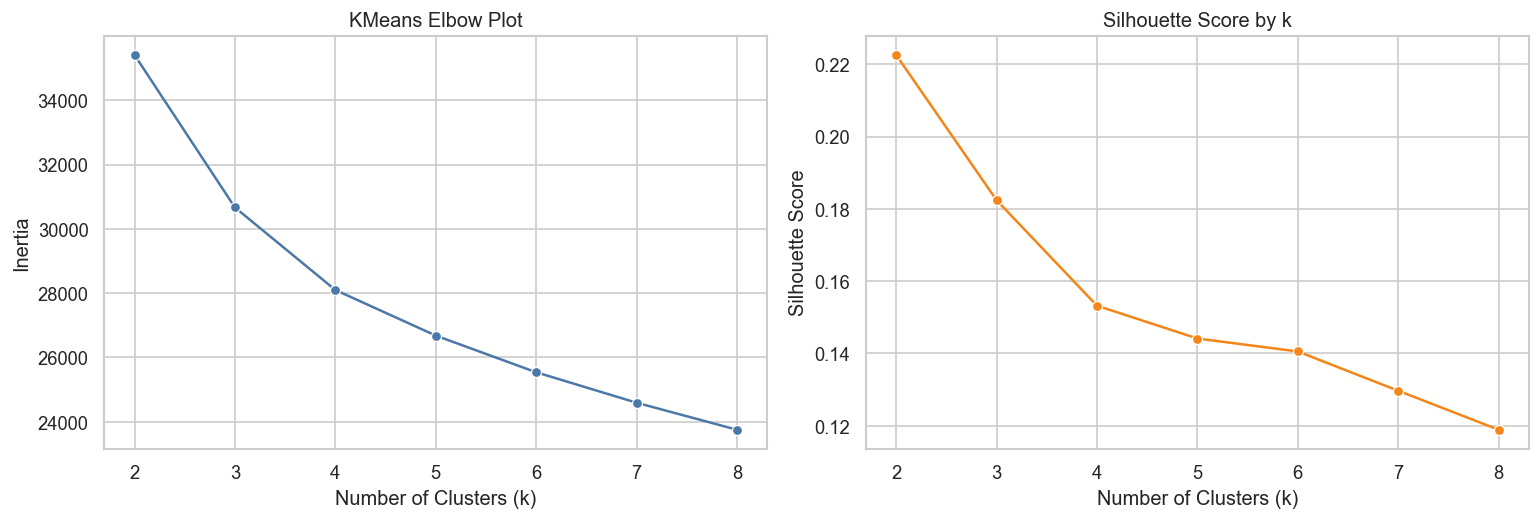

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.lineplot(data=evaluation_df, x="k", y="inertia", marker="o", ax=axes[0], color="#4C78A8")
axes[0].set_title("KMeans Elbow Plot")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].set_xticks(evaluation_df["k"])

sns.lineplot(data=evaluation_df, x="k", y="silhouette_score", marker="o", ax=axes[1], color="#F58518")
axes[1].set_title("Silhouette Score by k")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_xticks(evaluation_df["k"])

fig.tight_layout()
fig.savefig(FIGURE_DIR / "clustering_kmeans_evaluation.png", bbox_inches="tight")
plt.show()

## 5. Choose Final Cluster Count

The final pipeline uses **k = 4**.

The silhouette score is highest at k = 2, but two clusters would likely be too broad for the segmentation goal. The inertia curve shows a meaningful drop through k = 4 and smaller gains afterward, so k = 4 is a defensible balance between separation, simplicity, and having enough groups to profile in the next step.

## 6. Fit Final Model and Save Clustered Output

The final KMeans model is fit on the transformed and scaled clustering matrix. The cluster labels are added back to the original engineered dataframe as a new `cluster` column.

In [9]:
final_model = fit_final_kmeans(clustering_data.scaled_matrix, n_clusters=FINAL_K)
clustered_df = add_cluster_labels(df, final_model.labels_)
save_clustered_output(clustered_df, CLUSTERED_DATA_PATH)

print(f"Final k: {FINAL_K}")
print(f"Clustered dataframe shape: {clustered_df.shape}")
print(f"Saved clustered output to: {CLUSTERED_DATA_PATH}")

cluster_counts = clustered_df["cluster"].value_counts().sort_index()
display(cluster_counts.to_frame("customer_count"))
display(clustered_df[["id", "age", "income", "total_spending", "total_purchases", "total_campaign_acceptances", "cluster"]].head())

Final k: 4
Clustered dataframe shape: (2213, 54)
Saved clustered output to: /Users/arjun/Documents/Intro DS final/data/processed/customer_clustered.csv


,customer_count
cluster,
0,667
1,413
2,640
3,493


,id,age,income,total_spending,total_purchases,total_campaign_acceptances,cluster
0,5524,57,58138.0,1617,25,0,0
1,2174,60,46344.0,27,6,0,3
2,4141,49,71613.0,776,21,0,0
3,6182,30,26646.0,53,8,0,1
4,5324,33,58293.0,422,19,0,0


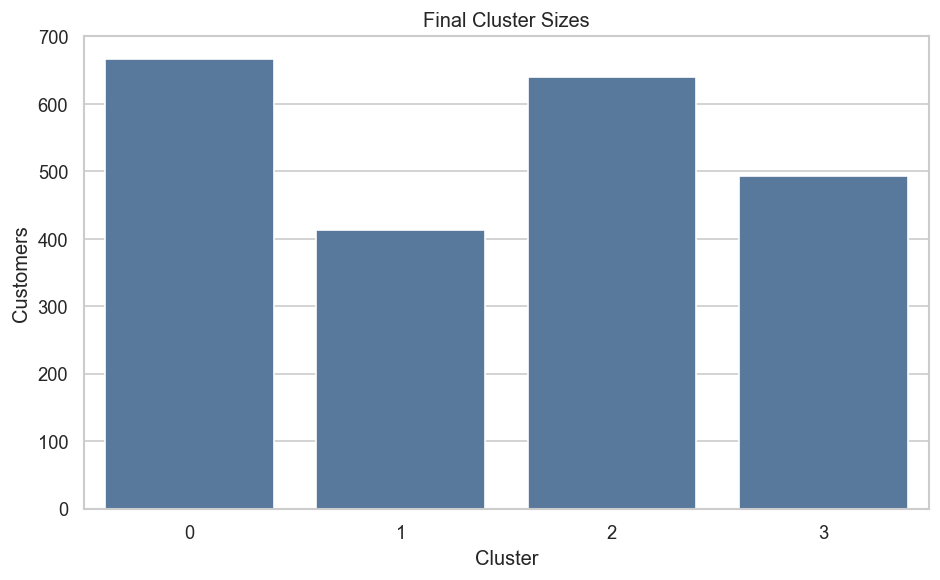

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=cluster_counts.index.astype(str), y=cluster_counts.values, ax=ax, color="#4C78A8")
ax.set_title("Final Cluster Sizes")
ax.set_xlabel("Cluster")
ax.set_ylabel("Customers")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "clustering_cluster_sizes.png", bbox_inches="tight")
plt.show()

## 7. PCA Visualization

PCA is used only for a two-dimensional visualization of the clustering results. It is not used to fit the KMeans model.

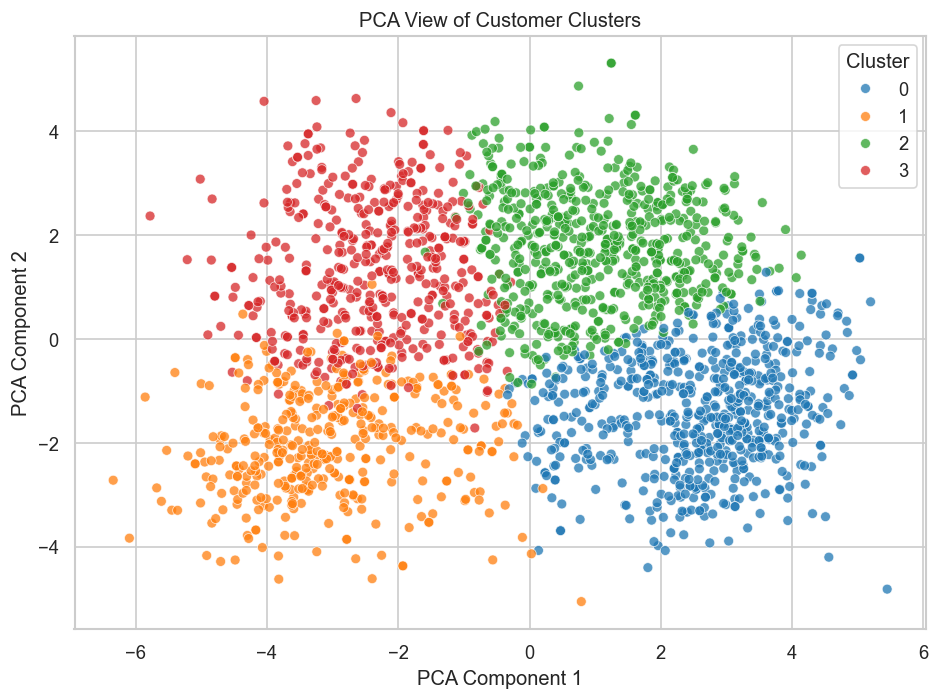

In [11]:
pca_df = create_pca_coordinates(clustering_data.scaled_matrix, final_model.labels_)

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=pca_df,
    x="pca_1",
    y="pca_2",
    hue="cluster",
    palette="tab10",
    s=35,
    alpha=0.75,
    ax=ax,
)
ax.set_title("PCA View of Customer Clusters")
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.legend(title="Cluster")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "clustering_pca_scatter.png", bbox_inches="tight")
plt.show()

## 8. Pipeline Validation

Confirm that the saved clustered dataset preserves all engineered rows and adds exactly one `cluster` column.

In [12]:
saved_clustered_df = pd.read_csv(CLUSTERED_DATA_PATH)

print(f"Original feature shape: {df.shape}")
print(f"Saved clustered shape: {saved_clustered_df.shape}")
print(f"Missing values in saved output: {int(saved_clustered_df.isna().sum().sum())}")
print(f"Infinite values in saved numeric output: {int(np.isinf(saved_clustered_df.select_dtypes(include=[np.number]).to_numpy()).sum())}")

assert saved_clustered_df.shape[0] == df.shape[0]
assert saved_clustered_df.shape[1] == df.shape[1] + 1
assert "cluster" in saved_clustered_df.columns
assert set(saved_clustered_df["cluster"].unique()) == set(range(FINAL_K))

Original feature shape: (2213, 53)
Saved clustered shape: (2213, 54)
Missing values in saved output: 0
Infinite values in saved numeric output: 0


## Notes for the Next Step

This notebook creates cluster labels but does not name or interpret the final customer segments. The next step should profile each cluster using the original readable features, compare segment behavior, and assign cautious labels based on evidence.

In [13]:
saved_figures = sorted(path.name for path in FIGURE_DIR.glob("clustering_*.png"))
print("Saved clustering figures:")
for figure in saved_figures:
    print(f"- {figure}")

Saved clustering figures:
- clustering_cluster_sizes.png
- clustering_kmeans_evaluation.png
- clustering_pca_scatter.png
